# Objective

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
df = pd.read_csv("../data/processed/cleaned_retail_data.csv")

In [3]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv(
    "../data/processed/cleaned_retail_data.csv"
)

# Dataset Overview

In [5]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSales,Year,Month,Day,Hour,DayOfWeek,DayName,IsWeekend,Season,InventoryLevel,CustomerTotalSales,HolidaySeason
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1,7,1,Tuesday,0,Winter,112,2017.2,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,7,1,Tuesday,0,Winter,445,2017.2,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,7,1,Tuesday,0,Winter,358,2017.2,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1,7,1,Tuesday,0,Winter,280,2017.2,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1,7,1,Tuesday,0,Winter,116,2017.2,1


In [6]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

In [7]:
reference_date = df["InvoiceDate"].max()

reference_date

Timestamp('2010-12-09 20:01:00')

In [8]:
rfm = df.groupby("Customer ID").agg({

    "InvoiceDate": lambda x:
    (reference_date - x.max()).days,

    "Invoice": "nunique",

    "TotalSales": "sum"

})

# RFM Analysis

In [9]:
rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

In [10]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,164,11,372.86
12347.0,2,2,1323.32
12348.0,73,1,222.16
12349.0,42,3,2671.14
12351.0,10,1,300.93


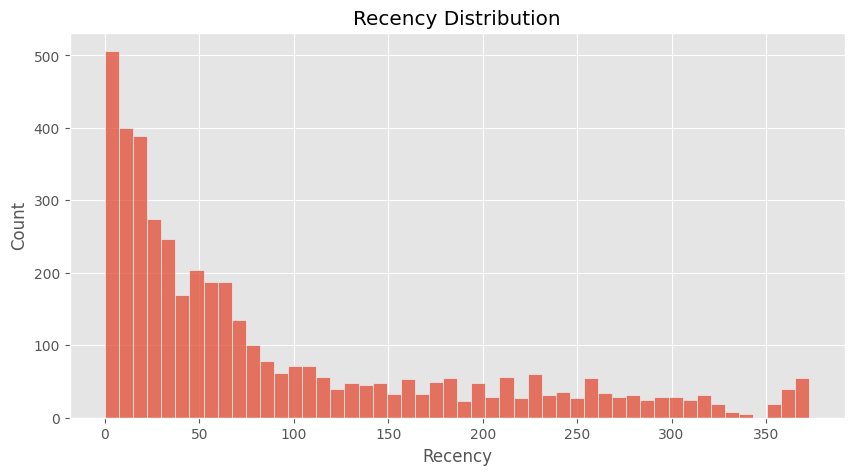

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(rfm["Recency"], bins=50)

plt.title("Recency Distribution")

plt.show()

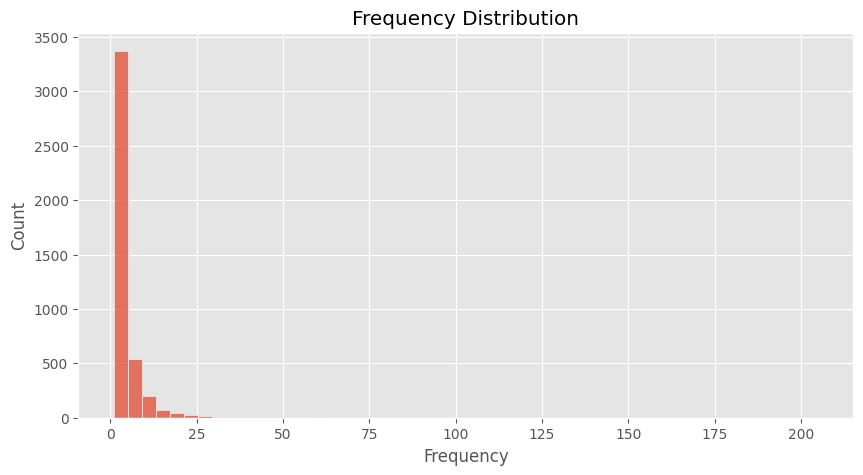

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(rfm["Frequency"], bins=50)

plt.title("Frequency Distribution")

plt.show()

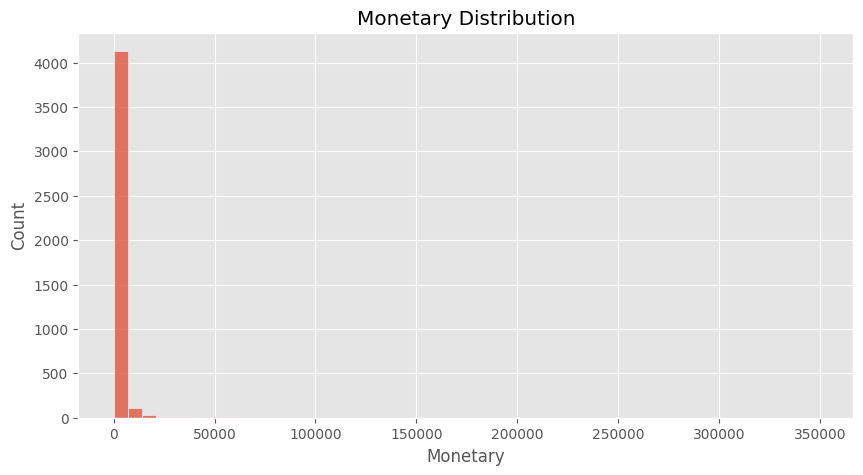

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(rfm["Monetary"], bins=50)

plt.title("Monetary Distribution")

plt.show()

In [14]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    4,
    labels=[4,3,2,1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4,
    labels=[1,2,3,4]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    4,
    labels=[1,2,3,4]
)

In [15]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

In [16]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346.0,164,11,372.86,1,4,2,142
12347.0,2,2,1323.32,4,2,3,423
12348.0,73,1,222.16,2,1,1,211
12349.0,42,3,2671.14,3,3,4,334
12351.0,10,1,300.93,4,1,1,411


# Conclusion

In [17]:
rfm.to_csv(
    "../data/processed/rfm_customer_segments.csv"
)